### Import bibliotek i konfiguracja

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.ensemble import VotingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split

RANDOM_STATE = 1
np.random.seed(RANDOM_STATE)

ADOPTION_SPEED_LABELS = {
    0: '0–7',
    1: '8–30',
    2: '31–90',
    3: '>100',
}
CLASS_ORDER = sorted(ADOPTION_SPEED_LABELS.keys())
CLASS_NAMES = [ADOPTION_SPEED_LABELS[c] for c in CLASS_ORDER]

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

### Wczytanie danych i modeli

In [3]:
PROCESSED_DIR = '../data/processed'
MODELS_DIR = Path('../models')
INPUT_PATH = f'{PROCESSED_DIR}/train_clean_anomaly.csv'

df = pd.read_csv(INPUT_PATH)
if 'is_anomaly' in df.columns:
    df = df.drop(columns=['is_anomaly'])

y = df['AdoptionSpeed']
X = df.drop(columns=['AdoptionSpeed'])

# Wczytanie modeli i listy cech
rf_model = joblib.load(MODELS_DIR / 'rf_best.pkl')
svm_model = joblib.load(MODELS_DIR / 'svm_best.pkl')
knn_model = joblib.load(MODELS_DIR / 'knn_best.pkl')
nn_model = joblib.load(MODELS_DIR / 'nn_best.pkl')
feature_names = joblib.load(MODELS_DIR / 'feature_names.pkl')

X = X[feature_names]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

# Skalowanie (dla SVM/KNN/MLP)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

# RF - dane nieskalowane
base_acc = {
    'Random Forest': accuracy_score(y_test, rf_model.predict(X_test)),
    'SVM': accuracy_score(y_test, svm_model.predict(X_test_scaled)),
    'KNN': accuracy_score(y_test, knn_model.predict(X_test_scaled)),
    'MLP': accuracy_score(y_test, nn_model.predict(X_test_scaled)),
}

print('\nAccuracy każdego z modeli')
display(pd.DataFrame({'accuracy': base_acc}).round(4))

X_train: (11875, 20), X_test: (2969, 20)

Accuracy każdego z modeli


,accuracy
Random Forest,0.4160
SVM,0.3907
KNN,0.3654
MLP,0.4015


### Hard Voting

Hard Voting
              precision    recall  f1-score   support

         0–7       0.39      0.45      0.42       695
        8–30       0.36      0.38      0.37       798
       31–90       0.36      0.16      0.23       642
        >100       0.49      0.61      0.55       834

    accuracy                           0.41      2969
   macro avg       0.40      0.40      0.39      2969
weighted avg       0.40      0.41      0.40      2969

Accuracy: 0.4143
F1 macro: 0.3898


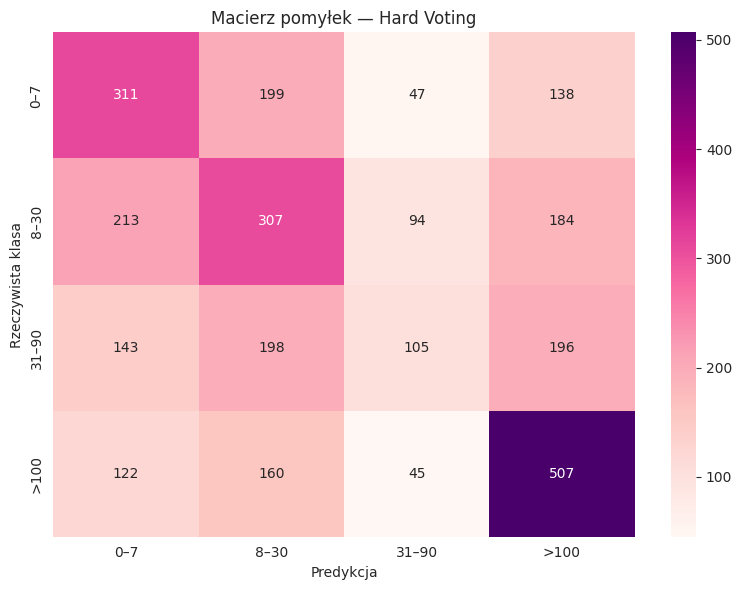

In [4]:
svm_pipe = Pipeline([('scaler', StandardScaler()), ('model', clone(svm_model))])
knn_pipe = Pipeline([('scaler', StandardScaler()), ('model', clone(knn_model))])
nn_pipe = Pipeline([('scaler', StandardScaler()), ('model', clone(nn_model))])

# SVM, KNN i MLP wymagaja skalowania, RF nie
estimators = [
    ('rf', clone(rf_model)),
    ('svm', svm_pipe),
    ('knn', knn_pipe),
    ('nn', nn_pipe),
]

hard_voting = VotingClassifier(estimators=estimators, voting='hard')
hard_voting.fit(X_train, y_train)

y_pred_hard = hard_voting.predict(X_test)

acc_hard = accuracy_score(y_test, y_pred_hard)
f1_hard = f1_score(y_test, y_pred_hard, average='macro')

print('Hard Voting')
print(classification_report(y_test, y_pred_hard, target_names=CLASS_NAMES))
print(f'Accuracy: {acc_hard:.4f}')
print(f'F1 macro: {f1_hard:.4f}')

cm_hard = confusion_matrix(y_test, y_pred_hard, labels=CLASS_ORDER)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_hard, annot=True, fmt='d', cmap='RdPu',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Macierz pomyłek — Hard Voting')
plt.xlabel('Predykcja')
plt.ylabel('Rzeczywista klasa')
plt.tight_layout()
plt.show()

### Weighted Voting

Wagi modeli:


,Model,Accuracy,Waga
0,Random Forest,0.4160,0.2643
1,SVM,0.3907,0.2483
2,KNN,0.3654,0.2322
3,MLP,0.4015,0.2551


Weighted Voting
              precision    recall  f1-score   support

         0–7       0.41      0.39      0.40       695
        8–30       0.35      0.37      0.36       798
       31–90       0.36      0.17      0.23       642
        >100       0.48      0.67      0.56       834

    accuracy                           0.42      2969
   macro avg       0.40      0.40      0.39      2969
weighted avg       0.40      0.42      0.40      2969

Accuracy: 0.4153
F1 macro: 0.3871


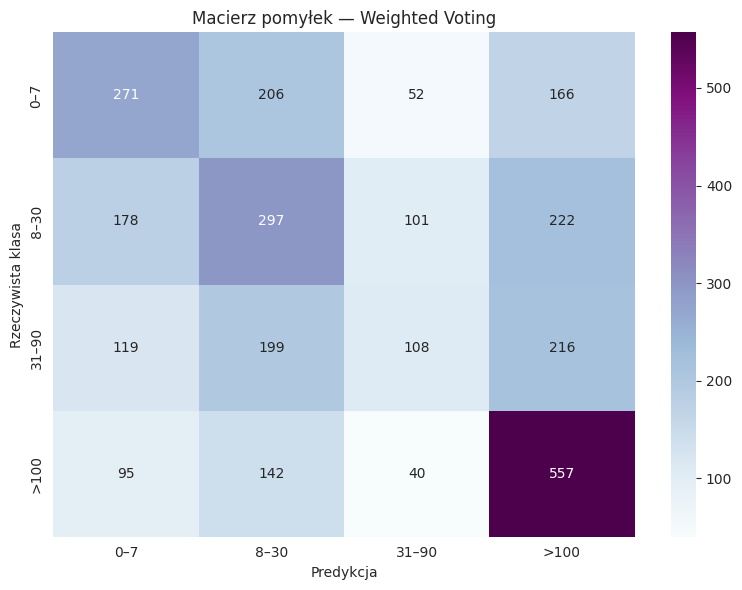

In [5]:
# Wagi proporcjonalne do accuracy 
acc_list = [base_acc['Random Forest'], base_acc['SVM'], base_acc['KNN'], base_acc['MLP']]
suma_acc = sum(acc_list)
weights = [a / suma_acc for a in acc_list]

wagi_tabela = pd.DataFrame({
    'Model': ['Random Forest', 'SVM', 'KNN', 'MLP'],
    'Accuracy': acc_list,
    'Waga': weights,
})
print('Wagi modeli:')
display(wagi_tabela.round(4))

weighted_voting = VotingClassifier(estimators=estimators, voting='hard', weights=weights)
weighted_voting.fit(X_train, y_train)

y_pred_weighted = weighted_voting.predict(X_test)

acc_weighted = accuracy_score(y_test, y_pred_weighted)
f1_weighted = f1_score(y_test, y_pred_weighted, average='macro')

print('Weighted Voting')
print(classification_report(y_test, y_pred_weighted, target_names=CLASS_NAMES))
print(f'Accuracy: {acc_weighted:.4f}')
print(f'F1 macro: {f1_weighted:.4f}')

cm_weighted = confusion_matrix(y_test, y_pred_weighted, labels=CLASS_ORDER)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_weighted, annot=True, fmt='d', cmap='BuPu',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Macierz pomyłek — Weighted Voting')
plt.xlabel('Predykcja')
plt.ylabel('Rzeczywista klasa')
plt.tight_layout()
plt.show()

### Porównanie

Porównanie metod głosowania:


,Accuracy,F1-macro
Hard Voting,0.4143,0.3898
Weighted Voting,0.4153,0.3871


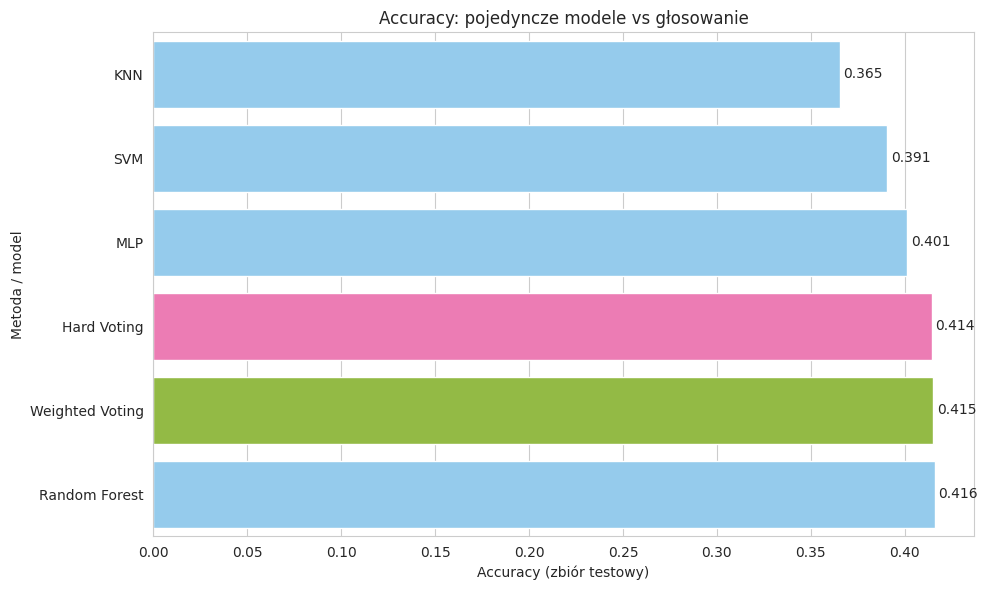

In [8]:
porownanie = pd.DataFrame({
    'Accuracy': [acc_hard, acc_weighted],
    'F1-macro': [f1_hard, f1_weighted],
}, index=['Hard Voting', 'Weighted Voting'])

print('Porównanie metod głosowania:')
display(porownanie.round(4))

all_acc = pd.Series({
    **base_acc,
    'Hard Voting': acc_hard,
    'Weighted Voting': acc_weighted,
}).sort_values()

kolory = ['lightskyblue'] * len(base_acc) + ['hotpink', 'yellowgreen']

kolor_map = {**{k: 'lightskyblue' for k in base_acc},
             'Hard Voting': 'hotpink', 'Weighted Voting': 'yellowgreen'}

plt.figure(figsize=(10, 6))
sns.barplot(x=all_acc.values, y=all_acc.index,
            hue=all_acc.index,
            palette=[kolor_map[k] for k in all_acc.index], legend=False)
for i, v in enumerate(all_acc.values):
    plt.text(v + 0.002, i, f'{v:.3f}', va='center')
plt.title('Accuracy: pojedyncze modele vs głosowanie')
plt.xlabel('Accuracy (zbiór testowy)')
plt.ylabel('Metoda / model')
plt.tight_layout()
plt.show()

### Predykcja dla nowych danych

In [15]:
nowe_zwierzeta = pd.DataFrame([
    # kot - mlody, zaszczepiony, odrobaczony, darmowy, duzo zdjec -> raczej szybka adopcja
    {'Type': 2, 'Age': 1, 'Breed1': 266, 'Breed2': 0, 'Gender': 2, 'Color1': 1, 'Color2': 2, 'Color3': 0,
     'MaturitySize': 1, 'FurLength': 1, 'Vaccinated': 1, 'Dewormed': 1, 'Sterilized': 1, 'Health': 1,
     'Quantity': 1, 'Fee': 0, 'VideoAmt': 0, 'PhotoAmt': 6, 'HasName': 1, 'DescLength': 220},
    # pies - starszy, niezaszczepiony, nieodrobaczony, niewysterylizowany, wysoka oplata, bez imienia, malo zdjec -> raczej wolna adopcja
    {'Type': 1, 'Age': 12, 'Breed1': 307, 'Breed2': 0, 'Gender': 1, 'Color1': 2, 'Color2': 0, 'Color3': 0,
     'MaturitySize': 3, 'FurLength': 2, 'Vaccinated': 2, 'Dewormed': 2, 'Sterilized': 2, 'Health': 2,
     'Quantity': 1, 'Fee': 300, 'VideoAmt': 0, 'PhotoAmt': 1, 'HasName': 0, 'DescLength': 40},
    # pies - mlody, zaszczepiony, odrobaczony, mala oplata, duzo zdjec -> raczej szybka adopcja
    {'Type': 1, 'Age': 4, 'Breed1': 189, 'Breed2': 0, 'Gender': 2, 'Color1': 1, 'Color2': 5, 'Color3': 0,
     'MaturitySize': 2, 'FurLength': 2, 'Vaccinated': 1, 'Dewormed': 1, 'Sterilized': 2, 'Health': 1,
     'Quantity': 1, 'Fee': 50, 'VideoAmt': 0, 'PhotoAmt': 7, 'HasName': 1, 'DescLength': 120},
    # 4 koty - mlode, niezaszczepione, odrobaczone, niewysterylizowane, darmowe, duzo zdjec -> srednia szybkosc adopcji
    {'Type': 2, 'Age': 2, 'Breed1': 266, 'Breed2': 0, 'Gender': 3, 'Color1': 1, 'Color2': 0, 'Color3': 0,
     'MaturitySize': 1, 'FurLength': 1, 'Vaccinated': 2, 'Dewormed': 1, 'Sterilized': 2, 'Health': 1,
     'Quantity': 4, 'Fee': 0, 'VideoAmt': 1, 'PhotoAmt': 8, 'HasName': 0, 'DescLength': 300},
    # kot - stary, zaszczepiony, odrobaczony, wysterylizowany, umiarkowana oplata, malo zdjec -> raczej wolna adopcja
    {'Type': 2, 'Age': 10, 'Breed1': 264, 'Breed2': 0, 'Gender': 1, 'Color1': 3, 'Color2': 6, 'Color3': 0,
     'MaturitySize': 3, 'FurLength': 1, 'Vaccinated': 1, 'Dewormed': 1, 'Sterilized': 1, 'Health': 1,
     'Quantity': 1, 'Fee': 100, 'VideoAmt': 0, 'PhotoAmt': 2, 'HasName': 1, 'DescLength': 80},
])[feature_names]

pred_hard = hard_voting.predict(nowe_zwierzeta)
pred_weighted = weighted_voting.predict(nowe_zwierzeta)

wyniki = pd.DataFrame({
    'Zwierzę': [f'zwierzę {i+1}' for i in range(len(nowe_zwierzeta))],
    'Hard Voting': [ADOPTION_SPEED_LABELS[c] for c in pred_hard],
    'Weighted Voting': [ADOPTION_SPEED_LABELS[c] for c in pred_weighted],
}).set_index('Zwierzę')

print('Predykcje systemu eksperckiego dla nowych zwierząt (dni do adopcji):')
display(wyniki)

Predykcje systemu eksperckiego dla nowych zwierząt (dni do adopcji):


,Hard Voting,Weighted Voting
Zwierzę,,
zwierzę 1,8–30,8–30
zwierzę 2,>100,>100
zwierzę 3,0–7,0–7
zwierzę 4,31–90,31–90
zwierzę 5,>100,>100
